# 4: Investigating Output

**BEFORE BEGINNING THIS EXERCISE** -  Check that your kernel (upper right corner, above) is `NPL 2023a`. This should be the default kernel, but if it is not, click on that button and select `NPL 2023a`.

_______________
This activity was developed primarily by Adrianna Foster.

## CLM and CLM-FATES output

You've run four cases spanning two land model structures and two vegetation configurations:

* CLM-SP: standard "big-leaf" CLM with satellite-prescribed phenology
* CLM-BGC: big-leaf CLM with prognostic biogeochemistry (carbon/nitrogen cycling, prognostic LAI)
* FATES-SP: FATES with satellite-prescribed phenology
* FATES-SP (modified parameters): the same FATES-SP configuration with a perturbed parameter file

Together these let you make three comparisons, each isolating a different piece:

1. CLM-SP vs. FATES-SP: same meteorology and prescribed phenology, different vegetation model.
2. FATES-SP vs. FATES-SP (modified): how FATES output responds to a parameter change.
3. CLM-SP vs. CLM-BGC: prescribed vs. prognostic vegetation within big-leaf CLM.

While CLM-FATES and big-leaf CLM share many output variables (mostly CLM quantities like `ASA`, `FSR`, and `FSH` that don't depend on the vegetation model) most vegetation-related quantities in a FATES run are simulated, calculated, and output by FATES itself. FATES variables carry their own names (typically prefixed `FATES_`), and their dimensions differ from big-leaf CLM: instead of the CLM PFT axis, FATES output is organized by FATES PFTs, size classes, and patch/cohort structure. Even the PFT definitions themselves differ between the two.

This notebook walks through some basic CLM and CLM-FATES output for the global cases you just ran, and shows how to do some basic comparisons.

*We will start by loading some packages.*

In [1]:
import os
import glob
import xarray as xr
import functools

%matplotlib inline

### Helper functions

These are a few helper functions that we will use in this notebook.

In [2]:
def preprocess(data_set: xr.Dataset, data_vars: list[str]) -> xr.Dataset:
    """Preprocesses an xarray Dataset by subsetting to specific variables - to be used on read-in

    Args:
        data_set (xr.Dataset): input Dataset

    Returns:
        xr.Dataset: output Dataset
    """

    return data_set[data_vars]


def annual_sum(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes annual sum

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual sum output
    """

    months = raw_values["time.daysinmonth"]
    return conversion_factor * (months * raw_values).groupby("time.year").sum()


def annual_mean(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes weighted annual mean using daysinmonth for missing-aware inputs.

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual mean output
    """

    months = raw_values["time.daysinmonth"]
    
    # multiply by number of days in month and conversion factor
    weighted = (raw_values * conversion_factor) * months

    # compute number of valid days per year
    valid_days = months.where(raw_values.notnull())

    # group and sum weighted data and valid days
    ann_sum = weighted.groupby("time.year").sum(dim="time", skipna=True)
    days_per_year = valid_days.groupby("time.year").sum(dim="time", skipna=True)

    return ann_sum / days_per_year.where(days_per_year > 0.0)

## 1. Reading and formatting data

**Note**: The exercises below assume you use `i.clm.sp`, `i.clm.bgc`, and `i.fates.year1` and `i.fates.year1.vcmax` output from the previous challenges for plotting for this section.

### 1.1 Read in the data
The first step is to grab the history files from the runs you completed in the challenge exercises. For these examples we will use gross primary production, latent heat flux, and sensible heat flux.

Two of these are CLM variables that share a name across all four cases:
- latent heat flux (`EFLX_LH_TOT`)
- sensible heat flux (`FSH`)

GPP is where the model structural differences show up. The variable name differs across all three configurations:

- **CLM-SP**: `FPSN` - photosynthesis rate (SP mode doesn't run the full carbon cycle, so there is no prognostic "GPP")
- **CLM-BGC**: `GPP` - gross primary production from the active biogeochemistry
- **FATES-SP**, **FATES-SP (modified)**: `FATES_GPP` - GPP calculated output by FATES

Note that the units for these variables are also all different! We will deal with this later...

In [4]:
# note: change the user here to your user name
user = 'afoster'

# per-case config: archive case name + the GPP-like variable
cases = {
    #'clm_sp': {'case': 'i.clm.sp.year1', 'gpp': 'FPSN'},  # SP big-leaf: photosynthesis rate
    #'clm_bgc': {'case': 'i.clm.bgc.month3', 'gpp': 'GPP'},  # prognostic BGC: true GPP
    'fates_sp': {'case': 'i.fates.year1', 'gpp': 'FATES_GPP'},  # FATES control
    'fates_vcmax': {'case': 'i.fates.year1.vcmax', 'gpp': 'FATES_GPP'},  # FATES, vcmax modified
}

# variables shared by every case
shared_vars = ['EFLX_LH_TOT', 'FSH', 'area', 'landfrac']

# FATES-only: gridcell fraction occupied by FATES
fates_vars = ['FATES_FRACTION']

# read in all datasets, supplying the correct `data_vars`
datasets = {}
for name, cfg in cases.items():
    hist = f"/glade/derecho/scratch/{user}/archive/{cfg['case']}/lnd/hist"
    files = sorted(glob.glob(os.path.join(hist, f"{cfg['case']}.clm2.h0a.*")))

    data_vars = shared_vars + [cfg['gpp']]
    if cfg['gpp'].startswith('FATES'):
        data_vars += fates_vars

    datasets[name] = xr.open_mfdataset(
        files,
        preprocess=functools.partial(preprocess, data_vars=data_vars),
    )

<b>NOTE:</b> These are the raw history files that CTSM writes out. 

By default, they include grid cell averaged monthly means for different state and flux variables.

<div class="alert alert-block alert-info">
    <b>TIP:</b> If you want to look at other variables, the <b>shared_vars</b> list in the cell above (for variables common to every case), the <b>fates_vars</b> list for variables only for FATES, or the <b>cases</b> config if you want to change the per-case GPP variable. Each case's read list is assembled from those.
</div>

#### Printing information about the dataset is helpful for understanding your data.

Let's start with one of the FATES cases:
- *What dimensions do your data have?*
- *What are the coordinate variables?*
- *What variables are we looking at?*
- *Is there other helpful information, or are there attributes in the dataset we should be aware of?*

In [5]:
# print information about the FATES control dataset
datasets['fates_sp']

<xarray.Dataset>
Dimensions:         (time: 12, lat: 96, lon: 144)
Coordinates:
  * time            (time) object 2000-01-16 12:00:00 ... 2000-12-16 12:00:00
  * lon             (lon) float64 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat             (lat) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
Data variables:
    EFLX_LH_TOT     (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FSH             (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    area            (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    landfrac        (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FATES_GPP       (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FATES_FRACTION  (time, lat, lon) float64 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
Attributes: (12/36)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 07/07/26 19:32:31
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_roof:                     71
    ctype_urban_sunwall:                  72
    ctype_urban_shadewall:                73
    ctype_urban_impervious_road:          74
    ctype_urban_pervious_road:            75
    time_period_freq:                     month_1

You can also print information about the variables in your dataset. The example below prints information about one of the data variables (`FATES_GPP`) we read in. You can modify this cell to look at some of the other variables in the dataset.

*What are the units, long name, and dimensions of your data?*

In [10]:
datasets['fates_sp'].FATES_GPP

<xarray.DataArray 'FATES_GPP' (time: 12, lat: 96, lon: 144)>
dask.array<concatenate, shape=(12, 96, 144), dtype=float64, chunksize=(1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2000-01-16 12:00:00 ... 2000-12-16 12:00:00
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
Attributes:
    long_name:      gross primary production in kg carbon per m2 per second
    units:          kg m-2 s-1
    cell_methods:   time: mean
    landunit_mask:  unknown

### 1.2 Simple Calculations

Before we can compare GPP across the four runs, we need to get them into the correct units and format. Two corrections are needed:

1. **`FATES_FRACTION` correction (FATES cases only)**: FATES doesn't know how much of each gridcell is occupied by natural vegetation, so the gridcell average implicitly assumes all of it is. We correct by multiplying the FATES history area-weighted values by `FATES_FRACTION`.

2. **Unit conversion (all cases)**: The three GPP-like variables come out in different units (`FPSN` as a photosynthesis rate in μmol CO<sub>2</sub> m<sup>-2</sup> s<sup>-1</sup>, `GPP` in gC m<sup>-2</sup> s<sup>-1</sup>, and `FATES_GPP` in kgC m<sup>-2</sup> s<sup>-1</sup>) We convert all three to a common gC m<sup>-2</sup> s<sup>-1</sup> so the runs are actually comparable.

We'll store the result under a common variable name (`GPP`) in every dataset.

In [7]:
GPP_CONVERSION = {
    'FPSN': 1e-6 * 12.011,  # umol CO2 m-2 s-1 -> gC m-2 s-1  (1e-6 mol/umol * 12.011 gC/mol)
    'GPP': 1.0,  # gC m-2 s-1 -> gC m-2 s-1  (already there)
    'FATES_GPP': 1000.0,  # kg C m-2 s-1 -> gC m-2 s-1  (1000 g/kg)
}

for name, cfg in cases.items():
    ds = datasets[name]
    gpp_orig = cfg['gpp']  # native GPP-like variable for this case
    da = ds[gpp_orig]

    # FATES only: correct for FATES fraction
    if gpp_orig.startswith('FATES'):
        da = da * ds['FATES_FRACTION']

    # unify units -> gC m-2 s-1
    gpp = da * GPP_CONVERSION[gpp_orig]
    gpp.attrs = dict(ds[gpp_orig].attrs)  # copy source attrs
    gpp.attrs['units'] = 'gC m-2 s-1'  # then fix the ones we changed
    gpp.attrs['long_name'] = 'gross primary production'
    ds['GPP'] = gpp  # common name across all four cases

After this, every dataset has a `GPP` in identical units, and we can now plot with this variable instead of using a different one for each dataset.

---
## 2. Basic plotting

### 2.1. Easy plots using xarray

To get a first look at the data, we can plot a year of data from one of the simulations. We'll start with **CLM-SP**, the first case you ran.

<div class="alert alert-block alert-info">
    <b>NOTE:</b> The plotting function only works with 1D or 2D data. Our data are 3D (time, lat, lon), so we need to specify a specific value `x`, `y`, and `col`.
</div>

- We'll plot GPP (variable = `GPP`). Note that we select the variable by specifying our dataset (here `datasets['clm_sp']`) and then the variable. 
- Because we standardized GPP in the previous step, this same code works for any of the four cases. Just swap `datasets['clm_sp']` for another key (e.g. `datasets['fates_sp']`).

*More plotting examples are on the [xarray web site](https://docs.xarray.dev/en/latest/user-guide/plotting.html)*

In [13]:
datasets['clm_sp']['GPP'].plot(x="lon", y="lat", col="time", col_wrap=4);

KeyError: 'clm_sp'

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_plot_monthly_gpp.png)

*<p style="text-align: left;"> Figure: Plotting solution for monthly GPP for our control simulation. </p>*
    
</details>
</div>

#### Question

 - What do you notice in the Northern Hemisphere over the course of the year?

### 2.2. Calculating differences

#### FATES-SP vs. FATES-SP (modified)

We can calculate the difference between the FATES control run and the one where we updated the vcmax parameter for PFT 1. The code below:

 - Calculates annual GPP for both simulations (converting the standardized gC m<sup>-2</sup> s<sup>-1</sup> fluxes to an annual kgC m<sup>-2</sup> yr<sup>-1</sup> total)
 - Weights by land fraction so we're only looking at land
 - Defines the difference as a new variable, `gpp_diff`

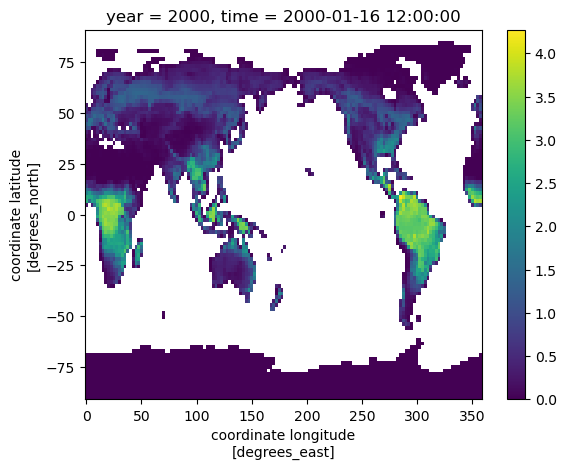

In [13]:
gpp_ann_control.plot()

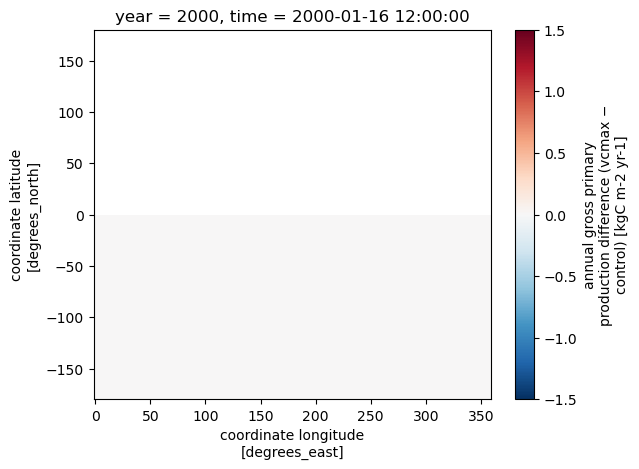

In [8]:
gpp_cf = 24 * 60 * 60 * 1e-3

fates_sp = datasets['fates_sp']
fates_vcmax = datasets['fates_vcmax']

gpp_ann_control = annual_sum(fates_sp.GPP, gpp_cf) * fates_sp.landfrac.isel(time=0)
gpp_ann_vcmax = annual_sum(fates_vcmax.GPP, gpp_cf) * fates_vcmax.landfrac.isel(time=0)

gpp_diff = gpp_ann_vcmax - gpp_ann_control
gpp_diff.attrs = {'units': 'kgC m-2 yr-1',
                  'long_name': 'annual gross primary production difference (vcmax − control)'}
gpp_diff.plot(cmap='RdBu_r', vmin=-1.5, vmax=1.5);

<div class="alert alert-success">
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_annual_gpp_diff.png)

*<p style="text-align: left;"> Figure: Plotting solution for annual GPP for our updated solution minus the control simulation. </p>*
    
</details>
</div>

##### Questions
- How is GPP different for FATES simulation with the updated parameter value, relative to the control FATES simulation?
- Where are the differences the largest?
- Where are they absent?

*<b>Hint</b>: you can check the `fates_pftname` variable in `/glade/u/home/$USER/code/my_cesm_code/CTSM/src/fates/parameter_files/fates_params_default.json` to see which PFT corresponds to which index.*

#### FATES-SP vs. CLM-SP 

Using the same methods, we can also compare our FATES-SP and CLM-SP cases:

In [17]:
clm_sp = datasets['clm_sp']

gpp_ann_clm = annual_sum(clm_sp.GPP,   gpp_cf) * clm_sp.landfrac.isel(time=0)
gpp_ann_fates = annual_sum(fates_sp.GPP, gpp_cf) * fates_sp.landfrac.isel(time=0)

gpp_diff_model = gpp_ann_fates - gpp_ann_clm
gpp_diff_model.attrs = {'units': 'kgC m-2 yr-1',
                        'long_name': 'annual GPP difference (FATES-SP − CLM-SP)'}
gpp_diff_model.plot(cmap='RdBu_r', vmin=-1.5, vmax=1.5);

KeyError: 'clm_sp'

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_monthly_gpp_pft.png)

*<p style="text-align: left;"> Figure: Plotting solution for comparing GPP by PFT for our updated simulation from our control. </p>*
    
</details>
</div>

#### Do the differences affect other variables?
To find out, we can plot `EFLX_LH_TOT`, which is latent heat flux. How do you think this will be affected?.

Unlike GPP, `EFLX_LH_TOT` is computed and gridcell-averaged by the CLM for every case, so it needs no `FATES_FRACTION` correction and no unit conversion. We take an annual mean here rather than a sum, since it's a flux density.

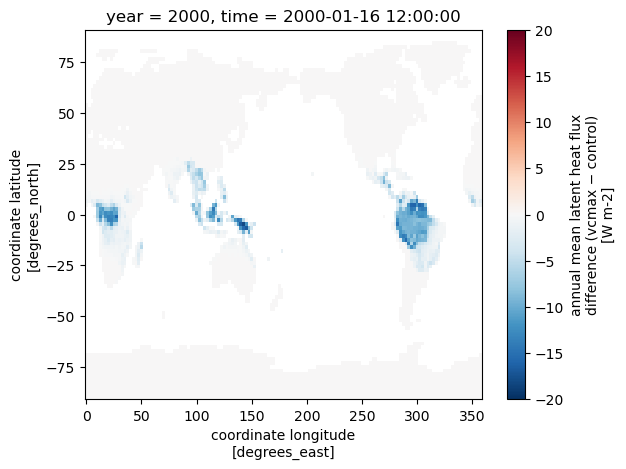

In [19]:
# latent heat flux difference: FATES control vs FATES vcmax 

lh_ann_control = annual_mean(fates_sp.EFLX_LH_TOT) * fates_sp.landfrac.isel(time=0)
lh_ann_vcmax = annual_mean(fates_vcmax.EFLX_LH_TOT) * fates_vcmax.landfrac.isel(time=0)

lh_diff_param = lh_ann_vcmax - lh_ann_control
lh_diff_param.attrs = {'units': 'W m-2',
                       'long_name': 'annual mean latent heat flux difference (vcmax − control)'}
lh_diff_param.plot(cmap='RdBu_r', vmin=-20, vmax=20);

In [18]:
# latent heat flux difference: CLM-SP vs FATES-SP

lh_ann_clm = annual_mean(clm_sp.EFLX_LH_TOT) * clm_sp.landfrac.isel(time=0)
lh_ann_fates = fates_sp.EFLX_LH_TOT.mean('time') * fates_sp.landfrac.isel(time=0)

lh_diff_model = lh_ann_fates - lh_ann_clm
lh_diff_model.attrs = {'units': 'W m-2',
                       'long_name': 'annual mean latent heat flux difference (FATES-SP − CLM-SP)'}
lh_diff_model.plot(cmap='RdBu_r', vmin=-20, vmax=20);

NameError: name 'clm_sp' is not defined

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_annual_lh_diff.png)

*<p style="text-align: left;"> Figure: Plotting solution for comparing latent heat flux for our updated simulation from our control. </p>*
    
</details>
</div>

##### Questions:
- How is latent heat flux different for the two FATES cases?
- What about FATES vs. CLM?
- Try looking at sensible heat flux (`FSH`). What differences do you see? 

*Note that you might want to change the minimun (`vmin`) and maximum (`vmax`) colorbar values for the plot when you change variables*

## 3. Comparing CLM-SP and CLM-BGC

The last comparison stays within big-leaf CLM: prescribed vs prognostic vegetation. In CLM-SP, LAI and vegetation height are prescribed; in CLM-BGC, the carbon–nitrogen cycle runs prognostically and vegetation state evolves with the simulation.

The BGC case only ran for a few months, so we can't take an annual total the way we did for the SP runs. Instead we will compare the two runs directly over the months they share.

In [ ]:
clm_bgc = datasets['clm_bgc']

# months available in the shorter BGC run
n_months = clm_bgc.time.size

clm_sp_short = clm_sp.isel(time=slice(0, n_months))

sec_per_day = 24 * 60 * 60
gpp_sp_mean = (clm_sp_short.GPP.mean('time') * sec_per_day) * clm_sp_short.landfrac.isel(time=0)
gpp_bgc_mean = (clm_bgc.GPP.mean('time') * sec_per_day) * clm_bgc.landfrac.isel(time=0)

gpp_diff_phen = gpp_bgc_mean - gpp_sp_mean
gpp_diff_phen.attrs = {'units': 'gC m-2 day-1',
                       'long_name': 'mean GPP difference over shared months (BGC − SP)'}
gpp_diff_phen.plot(cmap='RdBu_r', vmin=-5, vmax=5);